<a href="https://colab.research.google.com/github/Mahdi-Rashidiyan/My-Ai-project/blob/main/Persian_Alphabet_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import tensorflow as tf
import keras
import numpy as np
import cv2 as cv
import random
import matplotlib.pyplot as plt

In [4]:
%cd /content

/content


In [5]:
%pwd

'/content'

In [6]:
from roboflow import Roboflow
rf = Roboflow(api_key="OhaXBuHWLzwK4i1rCxMs")
project = rf.workspace("datasetyolov5-2k886").project("plate-alpha")
dataset = project.version(6).download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to plate-alpha-6 in folder:: 100%|██████████| 2218/2218 [00:00<00:00, 9471.08it/s]


In [7]:
train_path = '/content/plate-alpha-6/train'
valid_path = '/content/plate-alpha-6/valid'
test_path = '/content/plate-alpha-6/test'

In [8]:
class_names = subdirs = ['1-alef',
                         '2-b',
                         '3-p',
                         '4-t',
                         '5-se',
                         '6-jim',
                         '7-che',
                         '8-h',
                         '9-kh',
                         '10-d',
                         '11-zal',
                         '12-r',
                         '13-z',
                         '14-zh',
                         '15-sin',
                         '16-shin',
                         '17-sad',
                         '18-zad',
                         '19-t-long',
                         '20-z-long',
                         '21-ayin',
                         '22-ghyin',
                         '23-f',
                         '24-ghe',
                         '25-k',
                         '26-g',
                         '27-le',
                         '28-m',
                         '29-n',
                         '30-v',
                         '31-he',
                         '32-ye',
                         '33-zero',
                         '34-one',
                         '35-two',
                         '36-three',
                         '37-four',
                         '38-five',
                         '39-six',
                         '40-seven',
                         '41-eight',
                         '42-nine',
                         '43-anewfive']
num_classes = len(class_names)

In [9]:
print(len(class_names))

43


In [10]:
labels_nums = [i for i in range(0,len(class_names))]
print(labels_nums)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]


In [15]:
train_imgs = []
train_labels = []
for indx, subdir in enumerate(subdirs):
    imgfolder = os.path.join(train_path, subdir)
    # The following line was indented too far, it should be aligned with the previous line
    for imgname in os.listdir(imgfolder):
        img = cv.imread(os.path.join(imgfolder, imgname), 0)
        train_imgs.append(img)
        train_labels.append(labels_nums[indx])

c = list(zip(train_imgs, train_labels))
random.shuffle(c)
train_imgs, train_labels = zip(*c)

train_images = np.array(train_imgs)
train_labels = np.array(train_labels)

In [16]:
valid_imgs = []
valid_labels = []
for indx, subdir in enumerate(subdirs):
   imgfolder = os.path.join(valid_path, subdir)
   if os.path.exists(imgfolder):
     for imgname in os.listdir(imgfolder):
       img = cv.imread(os.path.join(imgfolder, imgname), 0)
       valid_imgs.append(img)
       valid_labels.append(labels_nums[indx])

c = list(zip(valid_imgs, valid_labels))
random.shuffle(c)
valid_imgs, valid_labels = zip(*c)

test_images = np.array(valid_imgs)
test_labels = np.array(valid_labels)

32-ye
31


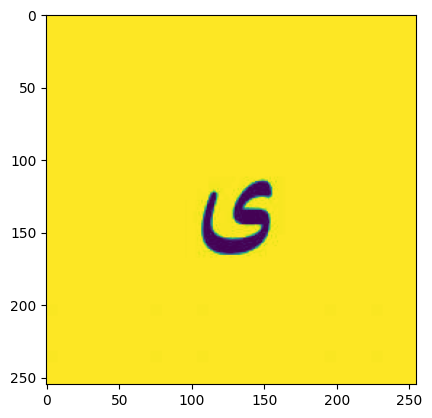

In [17]:
num=90
print(class_names[train_labels[num]])
print(train_labels[num])
plt.imshow(train_images[num])

In [18]:
test_labels

array([13, 15,  9, 10, 16,  0, 19, 21,  1, 10, 12, 17, 21, 17, 16, 14,  9,
       13, 19, 17, 18,  9, 10, 14, 20, 17, 10, 12, 12, 16, 16, 16, 19, 18,
       16,  9,  1, 22, 13, 10, 11, 16, 22, 18, 17,  9,  1, 14, 22, 20, 14,
       13, 22, 21, 12, 20, 21,  9, 11, 10, 17, 11, 13, 11,  0, 10, 11,  1,
       11, 22,  1, 19, 11, 20, 19, 10, 18, 19, 21, 13, 21,  1, 18, 16, 13,
       15, 14, 19, 13, 11, 13,  9,  1,  9, 15, 22, 19, 17, 13, 16,  9, 15,
        1, 13, 21, 14, 15, 17, 18])

In [20]:
#Normalization
train_images = train_images / 255.0
test_images = test_images / 255.0

In [22]:
model = keras.Sequential([

       keras.layers.Dropout(0.12),
       keras.layers.BatchNormalization(),


     # Flattening is used to convert all the resultant 2-Dimensional arrays from pooled feature maps into
     # a single long continuous linear vector. The flattened matrix is fed as input to the fully connected layer to classify the image
     keras.layers.Flatten(),
     keras.layers.BatchNormalization(),

     keras.layers.Dense(128, activation=tf.nn.relu),
     keras.layers.Dense(num_classes, activation=tf.nn.softmax)
 ])

In [23]:
model.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

In [25]:
model.fit(train_images, train_labels, epochs=48)

Epoch 1/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.5768 - loss: 1.6810
Epoch 2/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.6190 - loss: 1.4180
Epoch 3/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step - accuracy: 0.6726 - loss: 1.1560
Epoch 4/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 167ms/step - accuracy: 0.7342 - loss: 0.9090
Epoch 5/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.7547 - loss: 0.7286
Epoch 6/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 185ms/step - accuracy: 0.7668 - loss: 0.7379
Epoch 7/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - accuracy: 0.8003 - loss: 0.5730
Epoch 8/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.8028 - loss: 0.5636
Epoch 9/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.8333 - loss: 0.4863
Epoch 10/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.8149 - loss: 0.5529
Epoch 11/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 192ms/step - accuracy: 0.8203 - loss: 0.5287
Epoch 12/48
61/61 ━━━━━━━━━━━━━━━━━━━━ 21

In [29]:
model.save('/content/drive/MyDrive/saved_model/new.keras')

In [31]:
ocr_model = tf.keras.models.load_model('/content/drive/MyDrive/saved_model/new.keras', custom_objects={'softmax_v2': tf.keras.activations.softmax})

Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


Text(95.72222222222221, 0.5, 'Truth')

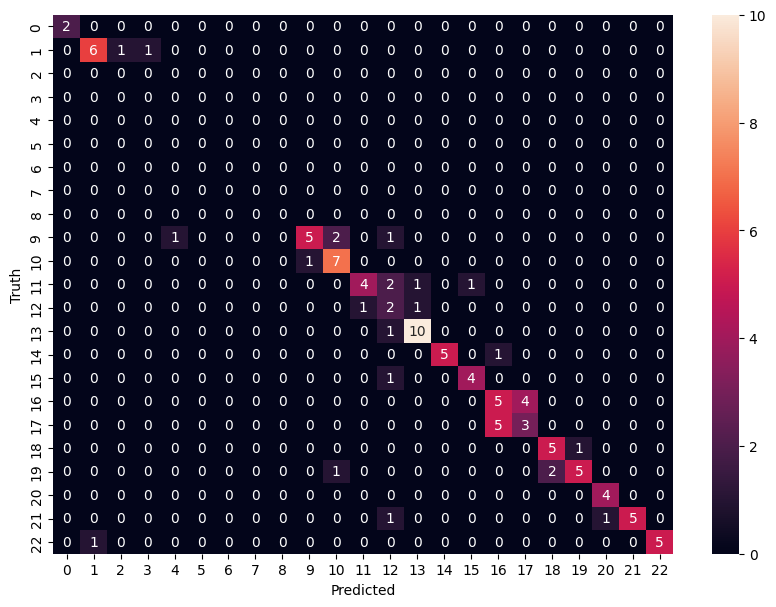

In [32]:
y_predicted = ocr_model.predict(test_images)
y_predicted_labels = [np.argmax(i) for i in y_predicted]

cm = tf.math.confusion_matrix(labels=test_labels, predictions=y_predicted_labels)

import seaborn as sn

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [33]:
predictions = ocr_model.predict(test_images)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [35]:
arr = np.array([10, 15,  9, 16, 13, 21, 13, 19, 21, 11, 17, 13,  0, 14, 17,  9, 13,
        19, 13, 22, 10, 18, 13, 19, 13,  1,  1, 12, 21, 12, 12, 19, 18, 13,
        13, 18, 17, 16, 21, 16, 11, 16,  9, 22, 16, 14,  9, 22, 11, 18, 13,
        21, 15, 14, 15,  9, 13,  1, 17, 10,  1, 14, 19, 20, 20, 15, 10, 18,
        17, 17,  1, 17, 14, 17, 10,  9, 16,  0, 10, 19, 20, 11, 21, 22, 21,
        12,  9, 11,  1,  9, 14, 22, 10, 11,  1, 10, 19, 16,  9, 16, 19, 20,
        22, 11, 18, 16, 15, 11,  1])


for v,l in enumerate(predictions[:5]):
     print(v,np.argmax(l))

0 12
1 15
2 4
3 10
4 16


In [36]:
for v,l in enumerate(predictions[:5]):
     print(v,class_names[np.argmax(l)])

0 13-z
1 16-shin
2 5-se
3 11-zal
4 17-sad


In [37]:
test_img_path = "/content/plate-alpha-6/train/40-seven/11seven_jpg.rf.5d6f7eb9dcd497c1d3cdb09b8225d615.jpg"
test_img = cv.imread(test_img_path, 0)
test_img = np.expand_dims(test_img, axis=0)
prediction1 = ocr_model.predict(test_img)

class_names[np.argmax(prediction1[0])]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


'8-h'